<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8014/blob/main/Tarea2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from ucimlrepo import fetch_ucirepo

In [ ]:
# ==========================================
# 1. CARGA Y PREPROCESAMIENTO DE DATOS
# ==========================================

print('1. Carga y prepocesamiento de datos')

# Descarga del dataset UCI Heart Disease
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy().values.ravel()

# Tratamiento rápido de valores nulos (típico en este dataset en variables 'ca' y 'thal')
X = X.fillna(X.median())

# Conversión de la variable objetivo a clasificación binaria (0: No enfermedad, 1-4: Enfermedad)
y = np.where(y > 0, 1, 0)

# División de datos: 70% entrenamiento, 30% prueba (según requerimiento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


1. Carga y prepocesamiento de datos


In [ ]:
y

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,

In [ ]:
# Función auxiliar para medir el tiempo exacto de predicción (fase crítica de KNN)
def medir_tiempo_knn(X_tr, X_te, y_tr, y_te, k=5, n_jobs=1):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=n_jobs)
    knn.fit(X_tr, y_tr)

    start_time = time.perf_counter()
    _ = knn.predict(X_te)
    end_time = time.perf_counter()

    return end_time - start_time


In [ ]:

# ==========================================
# 2. EXPERIMENTO A: ESCALABILIDAD EN MUESTRAS (n_train)
# ==========================================

print('2. Experimento A: Escalabilidad en muestras')

factores_n = [1, 2, 4, 8, 16]
tiempos_muestras = []
n_muestras = []

for f in factores_n:
    X_rep = np.tile(X_train, (f, 1))
    y_rep = np.tile(y_train, f)

    # Escalamos también el set de prueba de forma proporcional para simular el costo
    X_test_rep = np.tile(X_test, (f, 1))
    y_test_rep = np.tile(y_test, f)

    t = medir_tiempo_knn(
        X_rep, X_test_rep, y_rep, y_test_rep, k=5, n_jobs=1
    )
    tiempos_muestras.append(t)
    n_muestras.append(X_rep.shape[0])

2. Experimento A: Escalabilidad en muestras


In [ ]:
print(n_muestras)
print(tiempos_muestras)

[212, 424, 848, 1696, 3392]
[0.0044091940000043905, 0.002605326999969293, 0.004249780000009196, 0.008214988000077028, 0.01830003600002783]


In [ ]:
print('3. Experimento B: Escalabilidad en atributos')

factores_d = [1, 2, 4, 8]
tiempos_atributos = []
n_atributos = []

for f in factores_d:
    X_train_d = np.tile(X_train, (1, f))
    X_test_d = np.tile(X_test, (1, f))

    t = medir_tiempo_knn(X_train_d, X_test_d, y_train, y_test, k=5, n_jobs=1)
    tiempos_atributos.append(t)
    n_atributos.append(X_train_d.shape[1])


3. Experimento B: Escalabilidad en atributos


In [ ]:
print(n_atributos)
print(tiempos_atributos)

[13, 26, 52, 104]
[0.004540023000004112, 0.054278456000020014, 0.001352705000044807, 0.001419149999946967]


In [ ]:
# ==========================================
# 4. EXPERIMENTO C: ESCALABILIDAD FUERTE (p hilos, carga constante)
# ==========================================

print('4. Experimento C: Escalabilidad Fuerte (p hilos, carga constante')

procesos = [1, 2, 4, 8]
tiempos_fuerte = []

# Para escalabilidad fuerte fijamos un dataset grande (ej. factor x16) para que se aprecie el paralelismo
X_train_fuerte = np.tile(X_train, (16, 1))
y_train_fuerte = np.tile(y_train, 16)
X_test_fuerte = np.tile(X_test, (16, 1))
y_test_fuerte = np.tile(y_test, 16)

for p in procesos:
    t = medir_tiempo_knn(
        X_train_fuerte,
        X_test_fuerte,
        y_train_fuerte,
        y_test_fuerte,
        k=5,
        n_jobs=p,
    )
    tiempos_fuerte.append(t)

# Cálculos de Métricas Paralelas (Fuerte)
t1_fuerte = tiempos_fuerte[0]
speedup_fuerte = [t1_fuerte / tp for tp in tiempos_fuerte]
eficiencia_fuerte = [sp / p for sp, p in zip(speedup_fuerte, procesos)]

4. Experimento C: Escalabilidad Fuerte (p hilos, carga constante


In [ ]:
print(tiempos_fuerte)
print(speedup_fuerte)
print(eficiencia_fuerte)

[0.01823739300004945, 0.02770926599998802, 0.02652672299996084, 0.03005128200004492]
[1.0, 0.6581694729863049, 0.6875102137597763, 0.6068757066677618]
[1.0, 0.32908473649315245, 0.17187755343994407, 0.07585946333347023]


In [ ]:

# ==========================================
# 5. EXPERIMENTO D: ESCALABILIDAD DÉBIL (p hilos, carga aumenta con p)
# ==========================================

print('5. Experimento D: Escalabilidad Débil (p hilos, carga aumenta con p')

tiempos_debil = []

for p in procesos:
    # La carga de entrenamiento crece linealmente con el número de hilos p
    X_weak = np.tile(X_train, (p, 1))
    y_weak = np.tile(y_train, p)
    X_test_weak = np.tile(X_test, (p, 1))
    y_test_weak = np.tile(y_test, p)

    t = medir_tiempo_knn(
        X_weak, X_test_weak, y_weak, y_test_weak, k=5, n_jobs=p
    )
    tiempos_debil.append(t)

# Eficiencia Eficiente (Débil) = T1 / Tp
t1_debil = tiempos_debil[0]
eficiencia_debil = [t1_debil / tp for tp in tiempos_debil]


5. Experimento D: Escalabilidad Débil (p hilos, carga aumenta con p


In [ ]:
print(tiempos_debil)
print(eficiencia_debil)

[0.0030020759999160873, 0.013884132000043792, 0.014462254000022767, 0.015362566000021616]
[1.0, 0.2162235276866151, 0.20758009089809662, 0.1954150107418164]


6. Generación de Reportes Gráficos


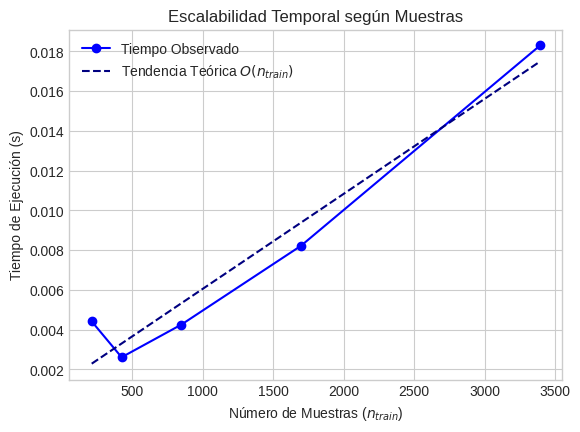

In [ ]:
# ==========================================
# 6. GENERACIÓN DE REPORTES GRÁFICOS
# ==========================================

print('6. Generación de Reportes Gráficos')

plt.figure(figsize=(14, 10))
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Gráfico 1: Tiempo vs Número de Muestras (Complejidad Teórica O(N))
plt.subplot(2, 2, 1)
plt.plot(n_muestras, tiempos_muestras, "o-", color="blue", label="Tiempo Observado")
# Ajuste lineal para representar la tendencia teórica O(N)
m, c = np.polyfit(n_muestras, tiempos_muestras, 1)
plt.plot(
    n_muestras,
    [m * x + c for x in n_muestras],
    "--",
    color="navy",
    label="Tendencia Teórica $O(n_{train})$",
)
plt.xlabel("Número de Muestras ($n_{train}$)")
plt.ylabel("Tiempo de Ejecución (s)")
plt.title("Escalabilidad Temporal según Muestras")
plt.legend()

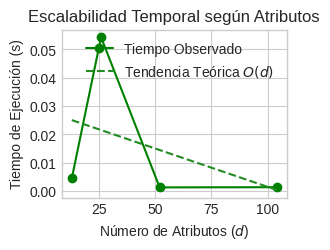

In [ ]:

# Gráfico 2: Tiempo vs Número de Atributos (Complejidad Teórica O(d))
plt.subplot(2, 2, 2)
plt.plot(
    n_atributos, tiempos_atributos, "o-", color="green", label="Tiempo Observado"
)
m_d, c_d = np.polyfit(n_atributos, tiempos_atributos, 1)
plt.plot(
    n_atributos,
    [m_d * x + c_d for x in n_atributos],
    "--",
    color="forestgreen",
    label="Tendencia Teórica $O(d)$",
)
plt.xlabel("Número de Atributos ($d$)")
plt.ylabel("Tiempo de Ejecución (s)")
plt.title("Escalabilidad Temporal según Atributos")
plt.legend()

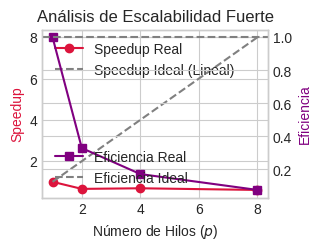

In [ ]:
# Gráfico 3: Escalabilidad Fuerte (Speedup y Eficiencia)
plt.subplot(2, 2, 3)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(procesos, speedup_fuerte, "o-", color="crimson", label="Speedup Real")
ax1.plot(procesos, procesos, "--", color="gray", label="Speedup Ideal (Lineal)")
ax2.plot(
    procesos,
    eficiencia_fuerte,
    "s-",
    color="purple",
    label="Eficiencia Real",
)
ax2.axhline(y=1.0, color="gray", linestyle="--", label="Eficiencia Ideal")
ax1.set_xlabel("Número de Hilos ($p$)")
ax1.set_ylabel("Speedup", color="crimson")
ax2.set_ylabel("Eficiencia", color="purple")
plt.title("Análisis de Escalabilidad Fuerte")
ax1.legend(loc="upper left")
ax2.legend(loc="lower left")


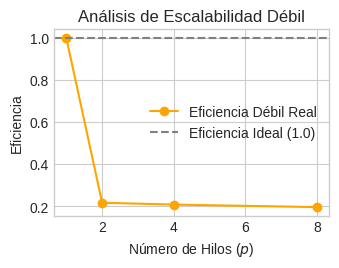

In [ ]:
# Gráfico 4: Escalabilidad Débil (Overhead y Eficiencia Débil)
plt.subplot(2, 2, 4)
plt.plot(
    procesos,
    eficiencia_debil,
    "o-",
    color="orange",
    label="Eficiencia Débil Real",
)
plt.axhline(y=1.0, color="gray", linestyle="--", label="Eficiencia Ideal (1.0)")
plt.xlabel("Número de Hilos ($p$)")
plt.ylabel("Eficiencia")
plt.title("Análisis de Escalabilidad Débil")
plt.legend()

plt.tight_layout()
plt.show()

7. Visualización de Overhead


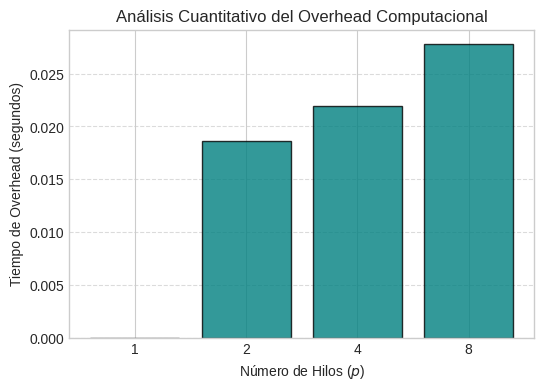

In [ ]:
print('7. Visualización de Overhead')

overhead_fuerte = [
    tp - (t1_fuerte / p) for tp, p in zip(tiempos_fuerte, procesos)
]

plt.figure(figsize=(6, 4))
plt.bar(
    [str(p) for p in procesos],
    overhead_fuerte,
    color="teal",
    alpha=0.8,
    edgecolor="black",
)
plt.xlabel("Número de Hilos ($p$)")
plt.ylabel("Tiempo de Overhead (segundos)")
plt.title("Análisis Cuantitativo del Overhead Computacional")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()